# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## Dataset Description

CIFAR-10 contains 60,000 color images of size 32×32.
There are 10 classes.

Training Images: 50,000
Testing Images: 10,000

## 🖼️ Visualize Sample Images

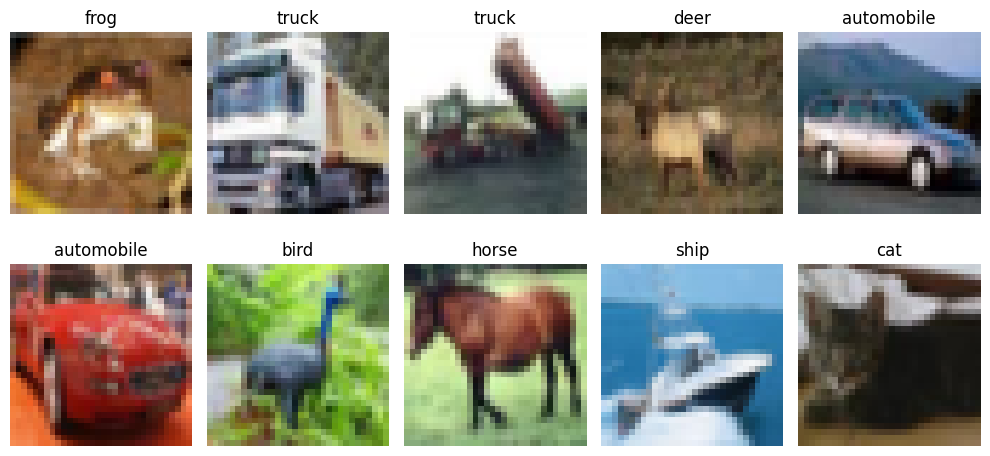

In [4]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## Sample Images

The figure below shows sample images from different CIFAR-10 categories.

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [5]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

## Data Preprocessing

Pixel values are scaled from 0–255 to 0–1.
Normalization helps the neural network train faster and more effectively.

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [6]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.2715 - loss: 1.9963 - val_accuracy: 0.3290 - val_loss: 1.8556
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3222 - loss: 1.8638 - val_accuracy: 0.3756 - val_loss: 1.7625
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.3366 - loss: 1.8190 - val_accuracy: 0.3556 - val_loss: 1.7942
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3581 - loss: 1.7701 - val_accuracy: 0.3872 - val_loss: 1.7365
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3648 - loss: 1.7526 - val_accuracy: 0.3970 - val_loss: 1.7170
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3702 - loss: 1.7296 - val_accuracy: 0.3912 - val_loss: 1.6948
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3796 - loss: 1.7027 - val_accuracy: 0.3938 - val_loss: 1.7099
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.3875 - loss: 1.6981 - 

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4357 - loss: 1.6121
ANN Test Accuracy: 0.435699999332428


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [8]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 68ms/step - accuracy: 0.4548 - loss: 1.5227 - val_accuracy: 0.4176 - val_loss: 1.5712
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.6011 - loss: 1.1371 - val_accuracy: 0.5954 - val_loss: 1.1584
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 66ms/step - accuracy: 0.6635 - loss: 0.9731 - val_accuracy: 0.6244 - val_loss: 1.0923
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 65ms/step - accuracy: 0.7027 - loss: 0.8512 - val_accuracy: 0.6152 - val_loss: 1.0988
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 65ms/step - accuracy: 0.7390 - loss: 0.7528 - val_accuracy: 0.6638 - val_loss: 1.0166
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 65ms/step - accuracy: 0.7664 - loss: 0.6709 - val_accuracy: 0.6432 - val_loss: 1.1699
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 66ms/step - accuracy: 0.7874 - loss: 0.6000 - val_accuracy: 0.7226 - val_loss: 0.8273
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 65ms/step - accuracy: 0.8059 - loss: 0.5475 - 

In [9]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6453 - loss: 1.3036
CNN Test Accuracy: 0.6452999711036682


## 📈 Compare Learning Curves

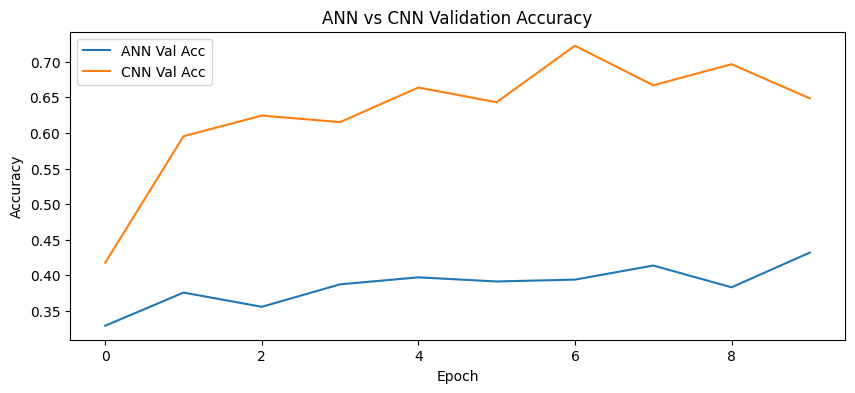

In [10]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

In [12]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [13]:
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 52ms/step - accuracy: 0.3558 - loss: 1.7659 - val_accuracy: 0.4756 - val_loss: 1.4341
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 52ms/step - accuracy: 0.4497 - loss: 1.5310 - val_accuracy: 0.5336 - val_loss: 1.2884
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.4896 - loss: 1.4286 - val_accuracy: 0.5400 - val_loss: 1.2855
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 51ms/step - accuracy: 0.5137 - loss: 1.3659 - val_accuracy: 0.5564 - val_loss: 1.2513
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.5338 - loss: 1.3167 - val_accuracy: 0.5946 - val_loss: 1.1338
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 52ms/step - accuracy: 0.5479 - loss: 1.2801 - val_accuracy: 0.5726 - val_loss: 1.2033
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 51ms/step - accuracy: 0.5555 - loss: 1.2559 - val_accuracy: 0.5806 - val_loss: 1.2305
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 51ms/step - accuracy: 0.5653 - loss: 1.2298 - 

In [15]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Accuracy:", aug_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6512 - loss: 0.9864
Augmented CNN Accuracy: 0.651199996471405


# 📊 Final Comparison Table

In [16]:
comparison = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN",
        "CNN + Augmentation"
    ],
    "Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        aug_test_acc
    ]
})

comparison

,Model,Accuracy
0,ANN,0.4357
1,CNN,0.6453
2,CNN + Augmentation,0.6512


## Conclusion  respective of cnn+augmentation

Three image classification models were evaluated on the CIFAR-10 dataset.

The ANN model achieved 43.57% accuracy but struggled because flattening images removes spatial information.

The CNN model improved performance to 64.53% by learning image features through convolutional layers.

Applying Data Augmentation and EarlyStopping further improved the model to 65.12%, demonstrating better generalization and reduced overfitting.

Performance Ranking:

CNN + Augmentation > CNN > ANN

This experiment highlights the importance of convolutional architectures and training strategies for image classification tasks.

# Advanced CNN (32→64→128 Filters)

In [17]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [18]:
improved_cnn = models.Sequential([

    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),

    layers.Flatten(),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
improved_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
history_improved = improved_cnn.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 75ms/step - accuracy: 0.6229 - loss: 1.0894 - val_accuracy: 0.6040 - val_loss: 1.1139
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 76ms/step - accuracy: 0.6354 - loss: 1.0561 - val_accuracy: 0.6644 - val_loss: 0.9585
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 75ms/step - accuracy: 0.6472 - loss: 1.0242 - val_accuracy: 0.6898 - val_loss: 0.9078
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 76ms/step - accuracy: 0.6585 - loss: 0.9931 - val_accuracy: 0.6442 - val_loss: 1.0229
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 54s 76ms/step - accuracy: 0.6649 - loss: 0.9767 - val_accuracy: 0.7104 - val_loss: 0.8338
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 76ms/step - accuracy: 0.6743 - loss: 0.9498 - val_accuracy: 0.7004 - val_loss: 0.8572
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 76ms/step - accuracy: 0.6805 - loss: 0.9259 - val_accuracy: 0.7192 - val_loss: 0.7960
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 54s 76ms/step - accuracy: 0.6905 - loss: 0.9067 - 

In [23]:
improved_loss, improved_acc = improved_cnn.evaluate(
    x_test_norm,
    y_test
)

print("Improved CNN Accuracy:", improved_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7120 - loss: 0.8337
Improved CNN Accuracy: 0.7120000123977661


In [24]:
comparison = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN",
        "CNN + Augmentation",
        "Improved CNN"
    ],
    "Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        aug_test_acc,
        improved_acc
    ]
})

comparison

,Model,Accuracy
0,ANN,0.4357
1,CNN,0.6453
2,CNN + Augmentation,0.6512
3,Improved CNN,0.7120


## Conclusion

Four image classification models were evaluated on the CIFAR-10 dataset.

The ANN model achieved 43.57% accuracy but performed poorly because flattening images removes spatial information.

The CNN model improved accuracy to 64.53% by learning spatial features through convolutional layers.

Adding Data Augmentation and EarlyStopping improved generalization and increased accuracy to 65.12%.

The Improved CNN, using deeper convolutional layers (32→64→128 filters), achieved the highest accuracy of 71.20%, demonstrating that deeper architectures can learn more complex image features.

Performance Ranking:

Improved CNN (71.20%) > CNN + Augmentation (65.12%) > CNN (64.53%) > ANN (43.57%)

This experiment demonstrates the importance of both network architecture and training strategies in image classification tasks.

# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**